# 03 — Visualizador de Detecções

Carrega os JSONs gerados pelo `02_detector_bolas` e exibe os resultados sobre as imagens normalizadas.

**Entrada:** `data/normalized/` + `data/output/*.json`  
**Use este notebook para:**
- Conferir visualmente se as bolas foram bem detectadas
- Identificar imagens problemáticas antes de gerar o dataset do Módulo 2
- Ver o resumo geral de todas as detecções

## Célula 1 — Imports e caminhos

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import json
import glob
import sys

NO_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ

if NO_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    CAMINHO_BASE = '/content/drive/MyDrive/Colab Notebooks/SinucaVision/data'
else:
    CAMINHO_BASE = os.path.join(os.path.dirname(os.getcwd()), 'data')

CAMINHO_NORMALIZED = os.path.join(CAMINHO_BASE, 'normalized')
CAMINHO_OUTPUT     = os.path.join(CAMINHO_BASE, 'output')

# ── Cores de visualização (BGR para OpenCV) ──────────────────────────────────
CORES_BGR = {
    'branca':   (230, 230, 230),
    'listrada': (0,   120, 255),   # azul
    'lisa':     (0,   0,   220),   # vermelho
    'cacapa':   (0,   0,   0),
}

print(f'Ambiente: {"Google Colab" if NO_COLAB else "Local"}')
print(f'Normalized: {CAMINHO_NORMALIZED}')
print(f'Output:     {CAMINHO_OUTPUT}')

Ambiente: Local
Normalized: /home/juliana/Projects/UFSC/visao/SinucaVision/data/normalized
Output:     /home/juliana/Projects/UFSC/visao/SinucaVision/data/output


## Célula 2 — Função de desenho

In [2]:
def desenhar_deteccoes(imagem_bgr, dados, espessura=2):
    """
    Desenha bolas e caçapas sobre uma cópia da imagem.
    Retorna a imagem anotada em RGB (pronta para matplotlib).
    """
    img = imagem_bgr.copy()

    # Caçapas
    for c in dados.get('cacapas', []):
        cv2.circle(img, (c['x'], c['y']), 18, (0, 0, 0), -1)
        cv2.circle(img, (c['x'], c['y']), 18, (180, 180, 180), 1)

    # Bolas
    for b in dados.get('bolas', []):
        cx, cy, raio, tipo = b['x'], b['y'], b['raio'], b['tipo']
        cor = CORES_BGR.get(tipo, (0, 255, 0))

        # Bola branca tem outline preto para se destacar no feltro claro
        if tipo == 'branca':
            cv2.circle(img, (cx, cy), raio + 5, (0, 0, 0), 2)

        cv2.circle(img, (cx, cy), raio + 3, cor, espessura)
        cv2.circle(img, (cx, cy), 2, (0, 255, 0), -1)   # centróide verde

        cv2.putText(
            img, tipo,
            (cx - 18, cy - raio - 6),
            cv2.FONT_HERSHEY_SIMPLEX, 0.4, cor, 1, cv2.LINE_AA
        )

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def carregar_par(nome_imagem):
    """
    Carrega a imagem normalizada e o JSON correspondente.
    Retorna (imagem_bgr, dados) ou (None, None) se não encontrar.
    """
    nome_base  = os.path.splitext(nome_imagem)[0]
    img_path   = os.path.join(CAMINHO_NORMALIZED, nome_imagem)
    json_path  = os.path.join(CAMINHO_OUTPUT, f'{nome_base}_balls.json')

    if not os.path.exists(img_path):
        print(f'Imagem não encontrada: {img_path}')
        return None, None
    if not os.path.exists(json_path):
        print(f'JSON não encontrado: {json_path}')
        print('Execute o notebook 02_detector_bolas antes de continuar.')
        return None, None

    imagem = cv2.imread(img_path)
    with open(json_path, 'r', encoding='utf-8') as f:
        dados = json.load(f)

    return imagem, dados


print('Funções carregadas.')

Funções carregadas.


## Célula 3 — Visualizar uma imagem específica

Altere `NOME_IMAGEM` para a foto que quer inspecionar.

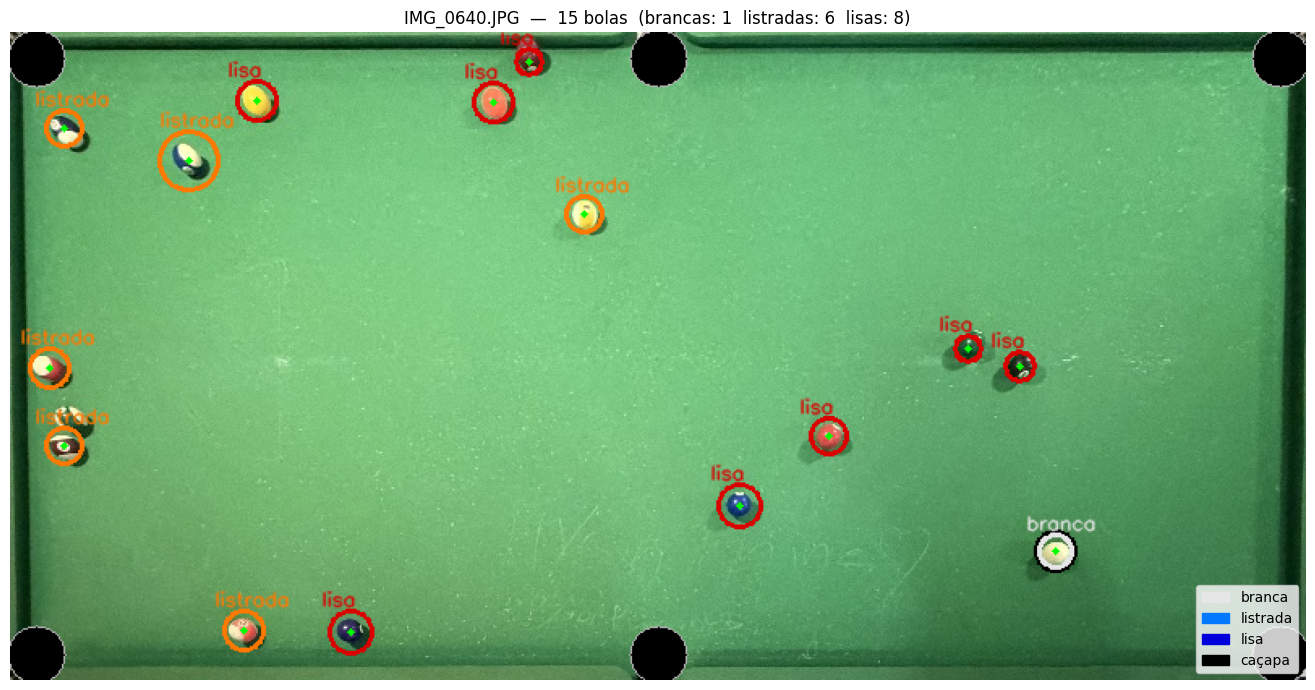

In [4]:
# ─── CONFIGURAÇÃO ───────────────────────────────────────────────────────────
NOME_IMAGEM = 'IMG_0640.JPG'
# ────────────────────────────────────────────────────────────────────────────

imagem, dados = carregar_par(NOME_IMAGEM)

if imagem is not None:
    img_anotada = desenhar_deteccoes(imagem, dados)

    n_bolas     = len(dados['bolas'])
    n_brancas   = sum(1 for b in dados['bolas'] if b['tipo'] == 'branca')
    n_listradas = sum(1 for b in dados['bolas'] if b['tipo'] == 'listrada')
    n_lisas     = sum(1 for b in dados['bolas'] if b['tipo'] == 'lisa')

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(img_anotada)
    ax.set_title(
        f'{NOME_IMAGEM}  —  {n_bolas} bolas  '
        f'(brancas: {n_brancas}  listradas: {n_listradas}  lisas: {n_lisas})',
        fontsize=12
    )
    ax.axis('off')

    # Legenda
    legend_items = [
        mpatches.Patch(color='#E6E6E6', label='branca'),
        mpatches.Patch(color='#0078FF', label='listrada'),
        mpatches.Patch(color='#0000DC', label='lisa'),
        mpatches.Patch(color='#000000', label='caçapa'),
    ]
    ax.legend(handles=legend_items, loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

## Célula 4 — Visualizar todas as imagens em grade

Mostra um thumbnail de cada imagem com o número de bolas detectadas.
Útil para identificar rapidamente quais imagens precisam de ajuste.

JSON não encontrado: /home/juliana/Projects/UFSC/visao/SinucaVision/data/output/IMG_0641_balls.json
Execute o notebook 02_detector_bolas antes de continuar.
JSON não encontrado: /home/juliana/Projects/UFSC/visao/SinucaVision/data/output/IMG_0642_balls.json
Execute o notebook 02_detector_bolas antes de continuar.
JSON não encontrado: /home/juliana/Projects/UFSC/visao/SinucaVision/data/output/IMG_0643_balls.json
Execute o notebook 02_detector_bolas antes de continuar.
JSON não encontrado: /home/juliana/Projects/UFSC/visao/SinucaVision/data/output/IMG_0644_balls.json
Execute o notebook 02_detector_bolas antes de continuar.
JSON não encontrado: /home/juliana/Projects/UFSC/visao/SinucaVision/data/output/IMG_0645_balls.json
Execute o notebook 02_detector_bolas antes de continuar.


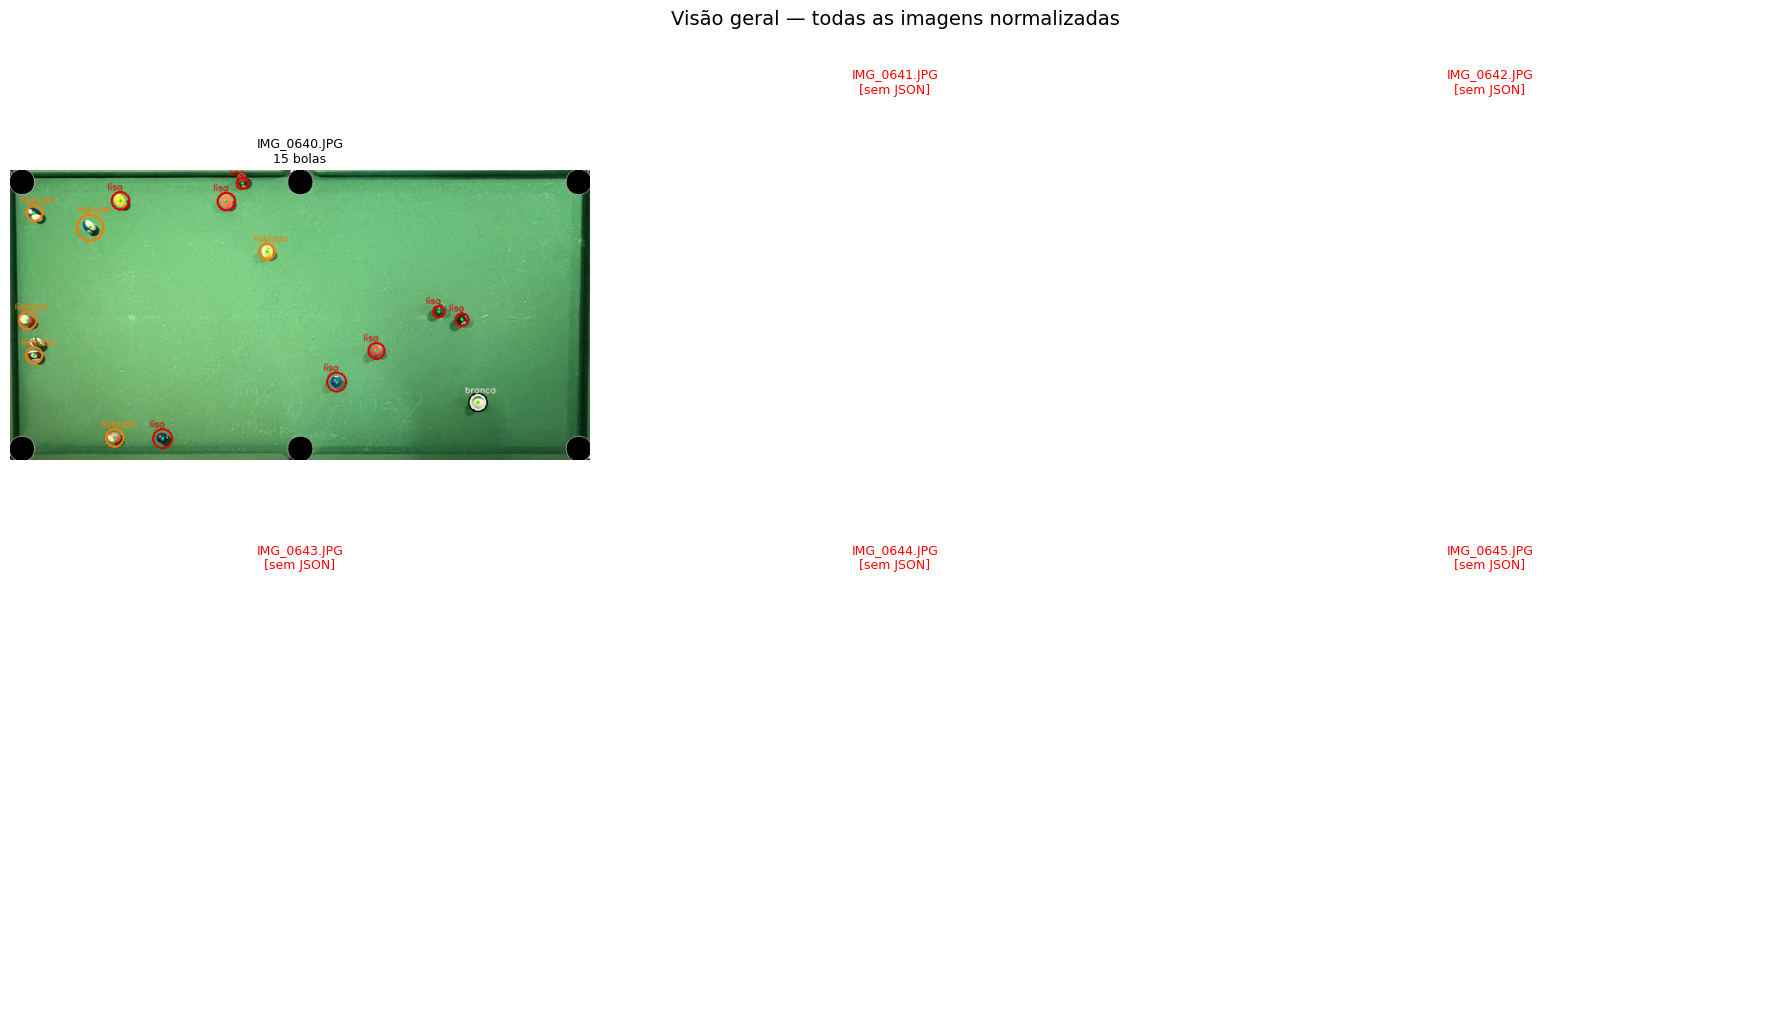


Total de imagens: 6
Com JSON:         1
Títulos vermelhos = 0 bolas detectadas ou > 16 (provável erro de detecção)


In [5]:
arquivos = sorted(glob.glob(os.path.join(CAMINHO_NORMALIZED, '*.JPG')))

if not arquivos:
    print('Nenhuma imagem encontrada em', CAMINHO_NORMALIZED)
else:
    n     = len(arquivos)
    colunas = 3
    linhas  = -(-n // colunas)  # ceil division

    fig, axes = plt.subplots(linhas, colunas, figsize=(18, 5 * linhas))
    axes = axes.flatten()

    for i, caminho_img in enumerate(arquivos):
        nome    = os.path.basename(caminho_img)
        imagem, dados = carregar_par(nome)

        if imagem is None:
            axes[i].set_title(f'{nome}\n[sem JSON]', color='red', fontsize=9)
            axes[i].axis('off')
            continue

        img_anotada = desenhar_deteccoes(imagem, dados)
        n_bolas = len(dados['bolas'])

        # Cor do título: vermelho se detectou 0 ou >16 bolas (provável erro)
        cor_titulo = 'red' if n_bolas == 0 or n_bolas > 16 else 'black'

        axes[i].imshow(img_anotada)
        axes[i].set_title(f'{nome}\n{n_bolas} bolas', fontsize=9, color=cor_titulo)
        axes[i].axis('off')

    # Oculta eixos vazios
    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle('Visão geral — todas as imagens normalizadas', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Resumo no terminal
    print(f'\nTotal de imagens: {n}')
    print(f'Com JSON:         {sum(1 for a in arquivos if os.path.exists(os.path.join(CAMINHO_OUTPUT, os.path.splitext(os.path.basename(a))[0] + "_balls.json")))}')
    print(f'Títulos vermelhos = 0 bolas detectadas ou > 16 (provável erro de detecção)')

## Célula 5 — Resumo estatístico de todas as detecções

In [6]:
jsons = sorted(glob.glob(os.path.join(CAMINHO_OUTPUT, '*_balls.json')))

if not jsons:
    print('Nenhum JSON encontrado. Execute o 02_detector_bolas primeiro.')
else:
    total_bolas     = 0
    total_brancas   = 0
    total_listradas = 0
    total_lisas     = 0
    contagens       = []

    for json_path in jsons:
        with open(json_path, 'r', encoding='utf-8') as f:
            dados = json.load(f)

        n = len(dados['bolas'])
        contagens.append((os.path.basename(json_path), n))
        total_bolas     += n
        total_brancas   += sum(1 for b in dados['bolas'] if b['tipo'] == 'branca')
        total_listradas += sum(1 for b in dados['bolas'] if b['tipo'] == 'listrada')
        total_lisas     += sum(1 for b in dados['bolas'] if b['tipo'] == 'lisa')

    print(f'Imagens processadas: {len(jsons)}')
    print(f'Total de bolas detectadas: {total_bolas}')
    print(f'  Brancas:   {total_brancas}')
    print(f'  Listradas: {total_listradas}')
    print(f'  Lisas:     {total_lisas}')
    print(f'  Média por imagem: {total_bolas / len(jsons):.1f}')
    print()

    print('Detalhamento por imagem:')
    for nome, n in contagens:
        flag = '  ⚠ ' if n == 0 or n > 16 else '    '
        print(f'{flag}{nome}: {n} bolas')

Imagens processadas: 1
Total de bolas detectadas: 15
  Brancas:   1
  Listradas: 6
  Lisas:     8
  Média por imagem: 15.0

Detalhamento por imagem:
    IMG_0640_balls.json: 15 bolas
